# data_overview

Translated from `data_overview.m` (repo root) of the Ye et al. 2023 spirals MATLAB repository.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from spirals_py.spirals import loadUVt1
from spirals_py.ephys import (
    get_MUA_bin,
    get_session_info2,
    get_wf2ephysT2,
    loadKSdir2,
)
from spirals_py.utils import (
    load_cell_array_h5,
    load_outline_coords_h5,
    overlayOutlines,
)

## load session table

In [2]:
DATA_FOLDER = data_root()  # MATLAB data release (SPIRALS_DATA_ROOT overrides)27850707
FIGURE_FOLDER = out_root() / "figures"  # figures also go to the python tree

## load widefield data

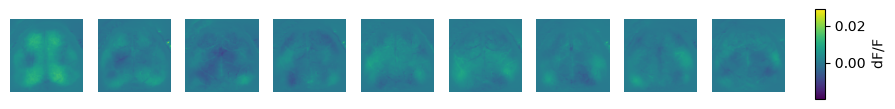

In [4]:
T = pd.read_excel(DATA_FOLDER / "tables" / "spiralSessions3.xlsx")  # read the session table
kk = 0  # take a look at first session in the table (MATLAB kk = 1)
mn = T.MouseID.iloc[kk]  # mouse name
tda = T.date.iloc[kk]  # session date
en = T.folder.iloc[kk]  # experiment folder
tdb = pd.Timestamp(tda).strftime("%Y%m%d")  # session date string (MATLAB datestr(tda,'yyyymmdd'))
subfolder = f"{mn}_{tdb}_{en}"  # full name identifier for the session
session_root = DATA_FOLDER / "spirals" / "svd" / subfolder  # svd data location for the session
U, V, t, mimg = loadUVt1(session_root)  # load svd components (U,V,t) from svd data folder
dV = np.hstack([np.zeros((V.shape[0], 1)), np.diff(V, axis=1)])  # derivative of the V components
U1 = U[:, :, :50].reshape(U.shape[0] * U.shape[1], 50)  # only use 50 components (>99% variance)
frames = np.arange(199, 208)  # MATLAB frames = 200:208 (1-based) -> 199..207
trace = U1 @ dV[:50][:, frames]  # reconstruct svd data to image space
trace = trace.reshape(U.shape[0], U.shape[1], trace.shape[1])  # reshape images to x*y*t matrix
trace = trace / mimg[:, :, None]  # normalize by mean intensity, to get df/f
frameN = len(frames)
cmin, cmax = trace.min(), trace.max()
fig, axes = plt.subplots(1, frameN, figsize=(10, 3))
for i in range(frameN):
    axes[i].imshow(trace[:, :, i], vmin=cmin, vmax=cmax)  # same color scale for all images
    axes[i].set_aspect("equal")
    axes[i].set_axis_off()
cax = fig.add_axes([0.93, 0.35, 0.01, 0.3])  # plot color scale bar
c = fig.colorbar(plt.cm.ScalarMappable(norm=plt.Normalize(cmin, cmax)), cax=cax)
c.set_label("dF/F")
plt.show()

## load axon morphology data

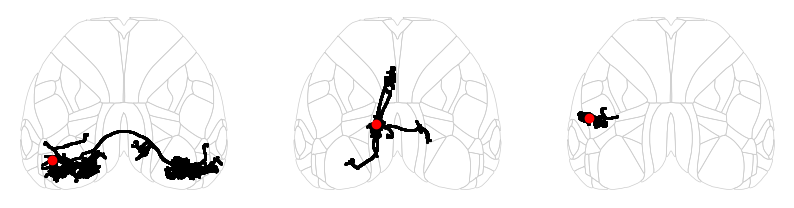

In [5]:
# both .mat files are MATLAB v7.3 (HDF5), so they are read with h5py-based helpers
allCoords = load_cell_array_h5(
    DATA_FOLDER / "axons" / "all_cell_with_parents.mat", "allCoords"
)  # single cell morphology dataset
coords = load_outline_coords_h5(
    DATA_FOLDER / "tables" / "isocortex_horizontal_projection_outline.mat"
)  # 10um resolution atlas horizontal view outlines
id_ = [82, 806, 799]  # let's take a look at these 3 random cells
somaType = 1  # soma coordinates are identified by type1 on the first data column
axonType = 2  # axons coordinates are identified by type2 on the first data column
scale = 1
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for i in range(3):
    ce1l1 = allCoords[id_[i] - 1]  # MATLAB allCoords{id(i)} (1-based cell index)
    axonCoords = ce1l1[ce1l1[:, 0] == axonType, 1:4]  # 3d coordinates of all axon points
    somaCoords = ce1l1[ce1l1[:, 0] == somaType, 1:4]  # 3d coordinates of all soma points
    overlayOutlines(coords, scale, [0.8, 0.8, 0.8], ax=axes[i])  # brain atlas outlines
    axes[i].invert_yaxis()  # MATLAB set(gca,'YDir','reverse')
    axes[i].plot(
        axonCoords[:, 2] / 10, axonCoords[:, 0] / 10, ".", color="k", markersize=1
    )  # plot all axons in 2d horizontal view, for simplicity
    axes[i].plot(
        somaCoords[:, 2] / 10, somaCoords[:, 0] / 10, ".", color="r", markersize=12
    )  # plot soma location
    axes[i].set_aspect("equal")
    axes[i].set_axis_off()
plt.show()

## load simultaneous widefield and ephys data

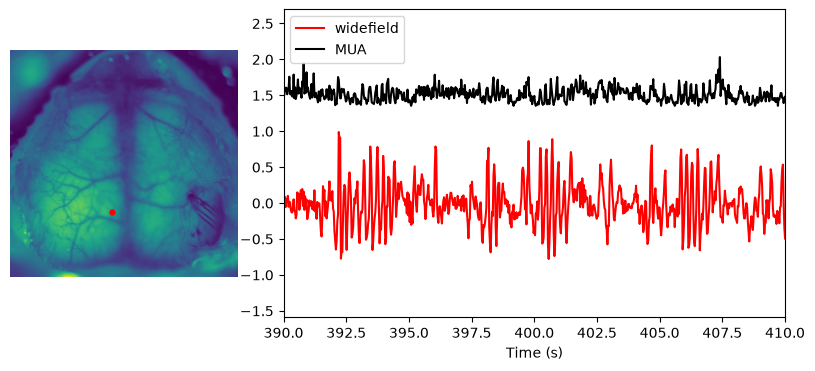

In [6]:
T = pd.read_csv(DATA_FOLDER / "tables" / "spirals_ephys_sessions.csv")
kk = 0
ops = get_session_info2(T, kk, DATA_FOLDER)  # get session info in a structure array
U, V, t, mimg = loadUVt1(ops.session_root)  # load U, V, t
dV = np.hstack([np.zeros((V.shape[0], 1)), np.diff(V, axis=1)])  # get derivative of V
sp = loadKSdir2(ops.session_root)  # load spike sorting results
syncTL, syncProbe, WF2ephysT1 = get_wf2ephysT2(ops, t)  # change widefield t to ephys spiketime t
notnan = ~np.isnan(WF2ephysT1)
WF2ephysT = WF2ephysT1[notnan]  # discard nan
nVc = 50  # how many components to use, 50 components contain >99% variance
dV1 = dV[:nVc][:, notnan].astype(float)
V1 = V[:nVc][:, notnan].astype(float)
tt1 = WF2ephysT1[notnan]
MUA_std = get_MUA_bin(sp, WF2ephysT)  # bin spiking data based on widefield T and sampling rate
# (the MATLAB script repeats the dV1 trim here, which would re-index the already-trimmed
# array; dV1 and MUA_std already have the same length in the time dimension)
pixelA = [399, 249]  # MATLAB pixelA = [400,250] (1-based [row,col]): example pixel in left RSP
traceA = U[pixelA[0], pixelA[1], :nVc] @ dV1  # reconstruct pixel trace from svd
traceA = traceA / mimg[pixelA[0], pixelA[1]]  # normalize by mean intensity, to get df/f
MUA_sum = MUA_std.sum(axis=0)  # sum all MUA activity
MUA_sum = MUA_sum / MUA_sum.max()  # normalize by max activity
fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(1, 3, 1)
ax1.imshow(mimg)
ax1.set_axis_off()
ax1.scatter(pixelA[1], pixelA[0], s=12, c="r")  # plot the RSP pixel on the widefield image
ax2 = fig.add_subplot(1, 3, (2, 3))
ax2.plot(tt1, traceA * 100, "r")  # plot widefield trace
ax2.plot(tt1, MUA_sum + 1.5, "k")  # plot spiking MUA trace
ax2.set_xlim(390, 410)  # let's zoom in on 20 seconds
ax2.legend(["widefield", "MUA"])
ax2.set_xlabel("Time (s)")
plt.show()